## PCA

### Task 1: Exploratory Data Analysis (EDA)

In [99]:
# Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',200)
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [13]:
# Loading the dataset
df=pd.read_csv('C:/Data Science/Assignments_Files/PCA/wine.csv')
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [15]:
# Creating copy of dataset for backup
df_copy=df.copy()

In [17]:
# Checking dataset size
df.shape

(178, 14)

In [19]:
# Checking Dataset columns
df.columns

Index(['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols',
       'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue',
       'Dilution', 'Proline'],
      dtype='object')

In [21]:
#Checking column's datatypes
df.dtypes

Type                 int64
Alcohol            float64
Malic              float64
Ash                float64
Alcalinity         float64
Magnesium            int64
Phenols            float64
Flavanoids         float64
Nonflavanoids      float64
Proanthocyanins    float64
Color              float64
Hue                float64
Dilution           float64
Proline              int64
dtype: object

In [23]:
# Summarizing statistical information
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [25]:
# Checking information about columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [27]:
# Checking duplicates
df.duplicated().sum()

0

In [29]:
# Checking for Null values
df.isna().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

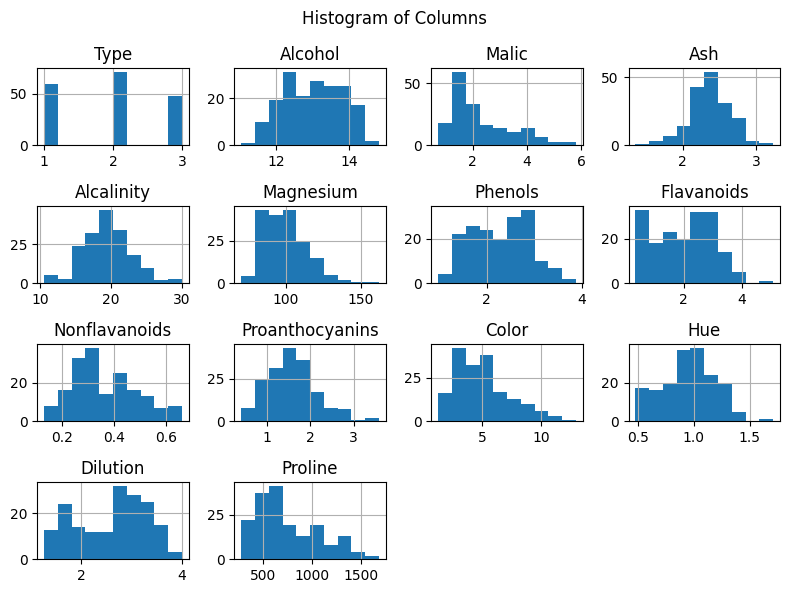

In [59]:
# Checking for distributions using Histogram
df.hist(figsize=(8,6))
plt.suptitle("Histogram of Columns")
plt.tight_layout()
plt.show()

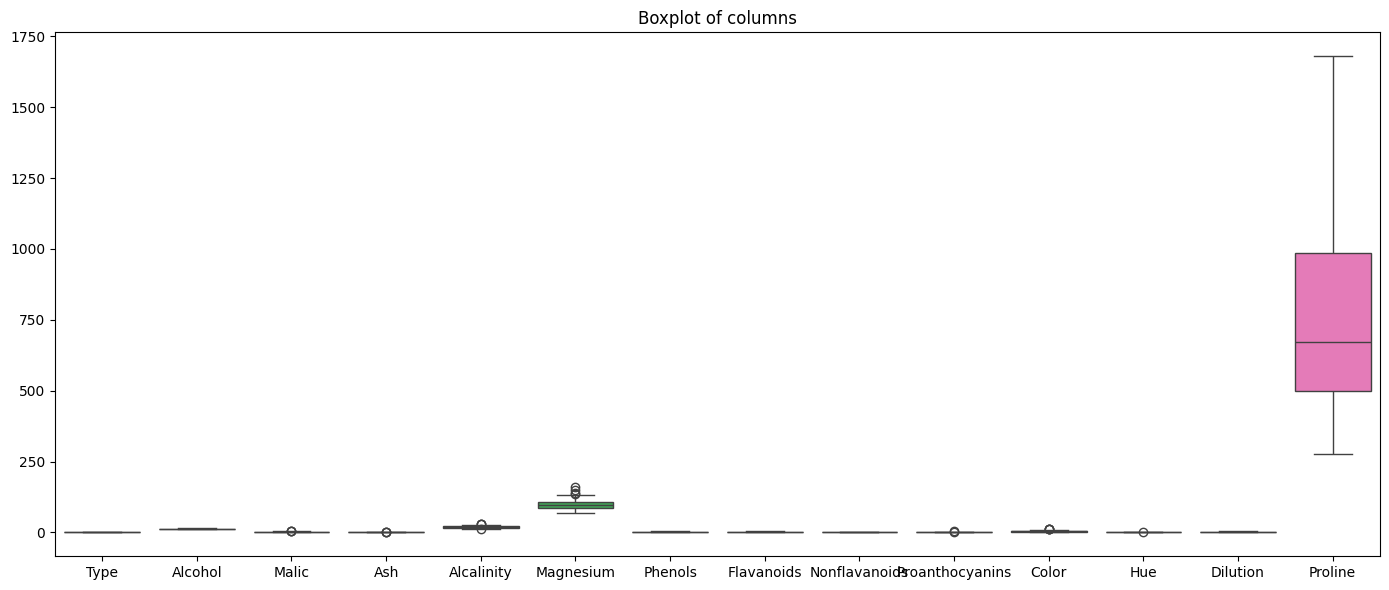

In [61]:
# Checking for boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.title("Boxplot of columns")
plt.tight_layout()
plt.show()

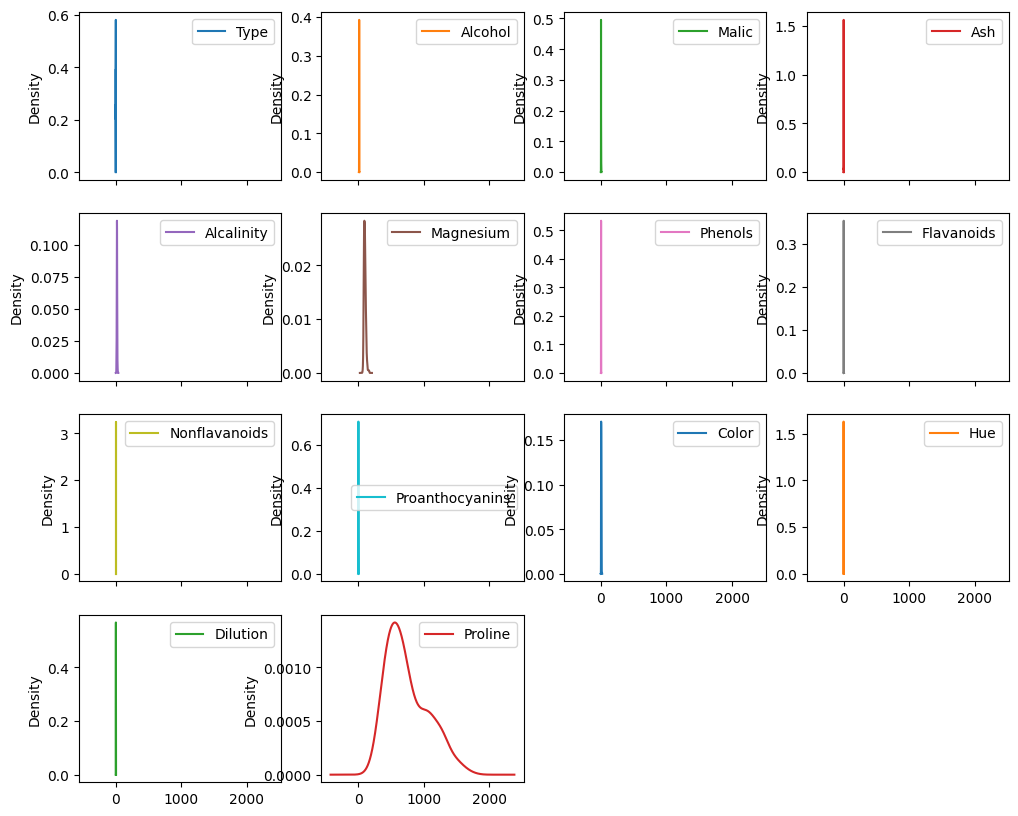

In [65]:
df.plot(kind='density', subplots=True, layout=(4,4), figsize=(12,10))
plt.show()

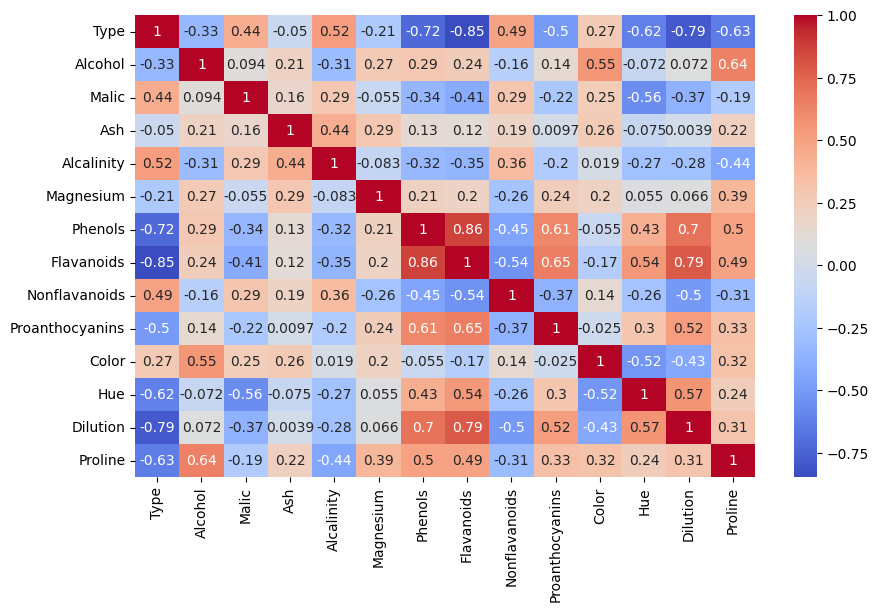

In [69]:
# Correlation Matrix
corr=df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

### Task 2: Dimensionality Reduction with PCA

In [76]:
# Standardizing features
scaler=StandardScaler()

In [82]:
# Target and Features declaration
X = df.drop('Type', axis=1)   # features
y = df['Type']                # target

In [84]:
# Standardizing data
X_scaled=scaler.fit_transform(X)

In [86]:
pca=PCA()
X_pca=pca.fit_transform(X_scaled)

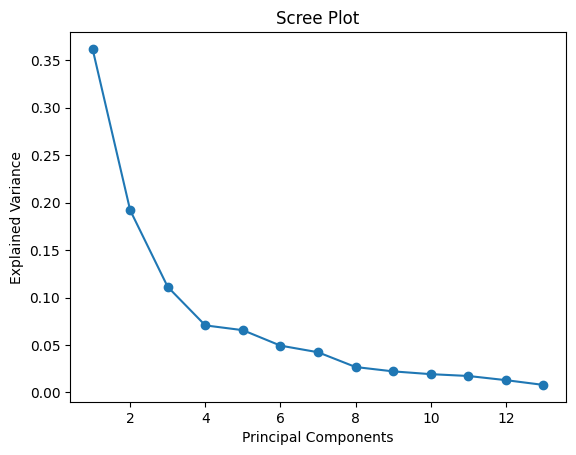

In [88]:
# Visulaizing Scree Plot
plt.plot(range(1,14), pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

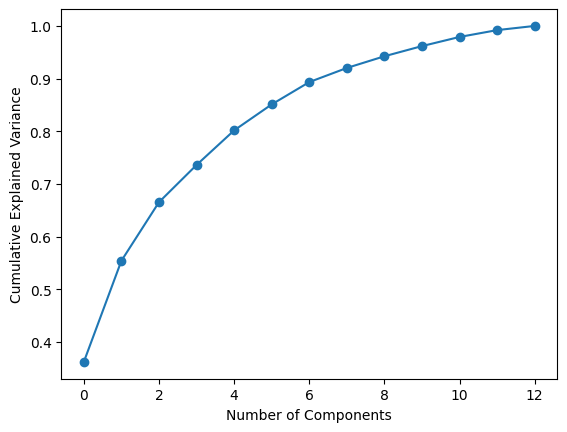

In [90]:
# Cumulative Explained Variance
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

In [92]:
# Reduce Dataset to 2 Components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [94]:
# Convert to DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df['Type'] = y

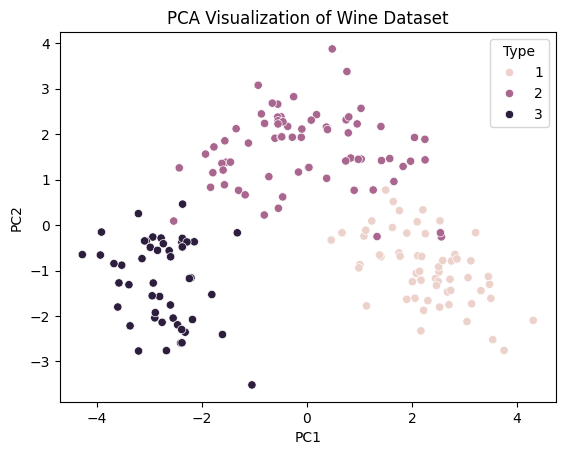

In [96]:
# Visualize PCA
sns.scatterplot(x='PC1', y='PC2', hue='Type', data=pca_df)
plt.title("PCA Visualization of Wine Dataset")
plt.show()

### Task 3: Clustering with Original Data

In [101]:
# Apply K-Means Clustering
X = df.drop('Type', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [103]:
# Adding clusters to Dataset
df['Cluster'] = clusters

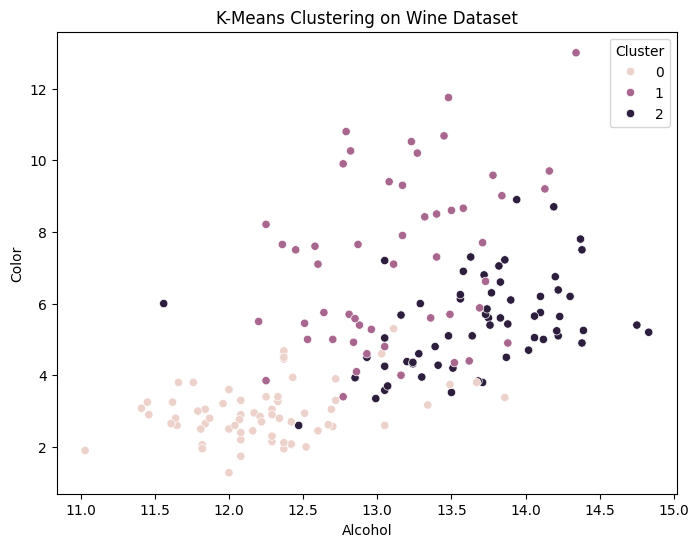

In [143]:
# Visualization of clustering results
plt.figure(figsize=(8,6))

sns.scatterplot(x=df['Alcohol'],y=df['Color'],hue=df['Cluster'])

plt.title("K-Means Clustering on Wine Dataset")
plt.show()

In [107]:
# Evaluate Clustering Performance

# 1. Using silhouette score 
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2848589191898987


In [109]:
# 2. Using Davies–Bouldin Index
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_scaled, clusters)

print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.3891879777181648


### Task 4: Clustering with PCA Data

In [112]:
# Apply K-Means on PCA Data
X = df.drop('Type', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [114]:
# Applying PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [118]:
# Applying K-Means on PCA-transformed dataset
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

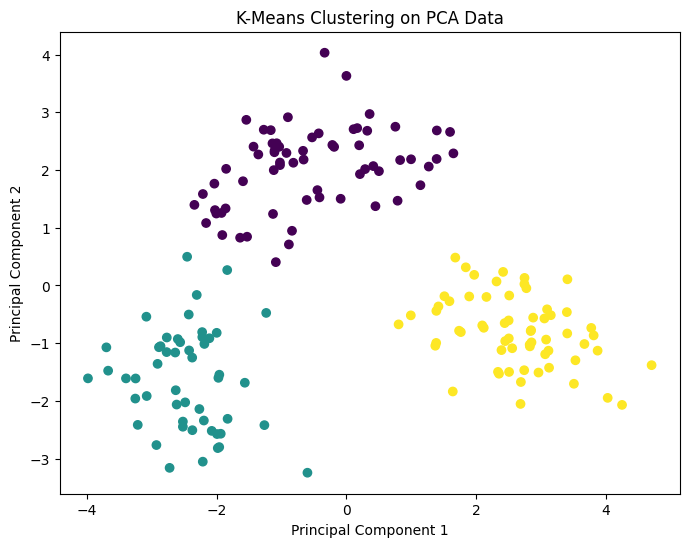

In [145]:
# Visualize PCA Clusters
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=clusters_pca,cmap='viridis')

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering on PCA Data")

plt.show()


In [122]:
# Evaluate Clustering Performance
from sklearn.metrics import silhouette_score

sil_pca = silhouette_score(X_pca, clusters_pca)

print("Silhouette Score (PCA):", sil_pca)

Silhouette Score (PCA): 0.6393654950929171


In [124]:
from sklearn.metrics import davies_bouldin_score

db_pca = davies_bouldin_score(X_pca, clusters_pca)

print("Davies-Bouldin Index (PCA):", db_pca)

Davies-Bouldin Index (PCA): 0.49947548094912775


### Task 5: Comparison and Analysis

In [133]:
sil_original = silhouette_score(X_scaled, clusters)
db_original = davies_bouldin_score(X_scaled, clusters)

sil_pca = silhouette_score(X_pca, clusters_pca)
db_pca = davies_bouldin_score(X_pca, clusters_pca)

In [135]:
# Compare Results Using a Table
comparison = pd.DataFrame({
    "Dataset": ["Original Data", "PCA Data"],
    "Silhouette Score": [sil_original, sil_pca],
    "Davies-Bouldin Index": [db_original, db_pca]
})

print(comparison)

         Dataset  Silhouette Score  Davies-Bouldin Index
0  Original Data          0.332194              1.238336
1       PCA Data          0.639365              0.499475


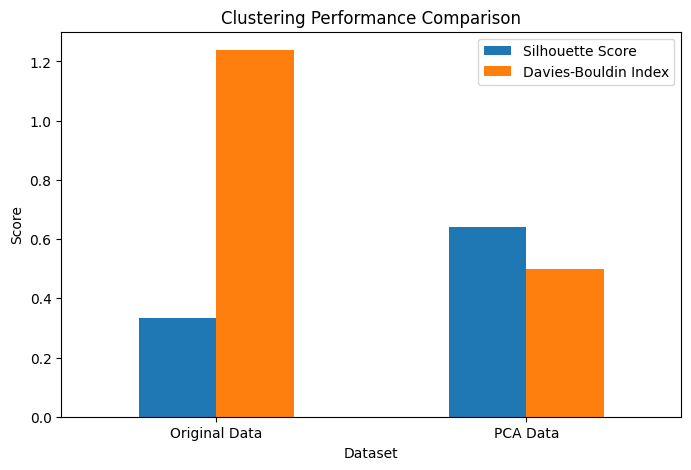

In [137]:
# Visual Comparison Plot
comparison.set_index("Dataset").plot(kind="bar", figsize=(8,5))
plt.title("Clustering Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

### Task 6: Conclusion and Insights

#### 1. Summary of Key Findings and Insights

In this assignment, exploratory analysis, dimensionality reduction, and clustering techniques were applied to the Wine Dataset. The original dataset contained several numerical features describing the chemical composition of different wine samples. After performing preprocessing and scaling, Principal Component Analysis was used to reduce the dimensionality of the dataset while preserving the most important variance in the data.

Clustering was then performed using K-means clustering on both the original dataset and the PCA-transformed dataset. The evaluation metrics showed a clear difference in clustering quality. The silhouette score increased from 0.332 in the original dataset to 0.639 after applying PCA, indicating stronger and more well-defined clusters. Additionally, the Davies–Bouldin index decreased from 1.238 to 0.499, which suggests improved separation and compactness of clusters. These results indicate that reducing dimensionality helped remove redundant information and allowed the clustering algorithm to identify clearer patterns in the data.

#### 2. Practical Implications of PCA and Clustering in Data Analysis
The combination of PCA and clustering plays an important role in analyzing complex datasets. PCA helps simplify high-dimensional data by transforming the original variables into a smaller set of components that capture the most significant variations. This not only reduces computational complexity but also makes visualization and interpretation easier.

Clustering, on the other hand, is useful for identifying hidden patterns or natural groupings within data without requiring predefined labels. In practical applications, clustering techniques are used in areas such as customer segmentation, market analysis, anomaly detection, and image analysis. When PCA is applied before clustering, it can help improve cluster quality by reducing noise and minimizing the impact of correlated variables. This often leads to more meaningful groupings and better analytical insights.

#### 3.Recommendations for Using PCA and Clustering

Based on the analysis conducted in this assignment, PCA is most beneficial when working with datasets that contain a large number of correlated features or when dimensionality makes visualization and computation difficult. By reducing the number of variables while preserving most of the information, PCA can simplify the dataset and improve the efficiency of machine learning algorithms.

Clustering can be applied directly to the original dataset when the number of features is relatively small and when preserving the interpretability of the original variables is important. However, when dealing with high-dimensional data, applying PCA before clustering is often recommended. This approach helps remove redundancy, improve cluster separation, and produce clearer visualizations, as observed in the results of this analysis.